# Agentes de IA I: Fundamentos
## Loops, Prompts y Herramientas

En las sesiones anteriores construimos modelos — transformers que generan texto.
En esta sesión damos el siguiente paso: convertir un modelo en un **agente** que
percibe su entorno, razona y ejecuta acciones.

**Objetivos:**
- Entender qué es un agente y cómo funciona el loop de razonamiento
- Distinguir cuándo usar IA y cuándo usar código determinista
- Construir un agente funcional usando la API de Claude con herramientas reales

## 1. Instalación y Configuración

In [2]:
# Instalar el SDK de Anthropic (solo necesario en Google Colab)
# !pip install anthropic

In [ ]:
import anthropic
import json
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Configurar el cliente de la API
# Opción 1: variable de entorno ANTHROPIC_API_KEY (recomendado)
# Opción 2: pasar la clave directamente (solo para pruebas)
client = anthropic.Anthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY", "tu-api-key-aqui")
)

MODEL = "claude-sonnet-4-6"
print(f"Cliente configurado. Modelo: {MODEL}")

Cliente configurado. Modelo: claude-sonnet-4-6


---
## 2. ¿Qué es un Agente?

Un **agente de IA** es un sistema que ejecuta un ciclo de:

```
  Observación → Razonamiento → Acción → Nueva Observación
       ↑                                        │
       └────────────────────────────────────────┘
```

La diferencia con una llamada simple al LLM:

| | Llamada simple | Agente |
|--|--|--|
| Pasos | 1 | Múltiples |
| Herramientas | No | Sí |
| Estado | No | Sí |
| Decisiones | No | Sí |

El agente **decide** qué hacer y en qué orden.
El código determinista **ejecuta** cada acción con precisión.

---
## 3. IA vs Procesos Deterministas

Los agentes son sistemas **híbridos**: el LLM decide *qué* hacer,
el código determinista lo *ejecuta* con precisión.

**Usa código determinista para:**
- Cálculos matemáticos exactos
- Acceso a bases de datos o archivos
- Validaciones y transformaciones de datos

**Usa IA para:**
- Interpretar lenguaje natural ambiguo
- Decidir qué herramienta usar y cuándo
- Sintetizar resultados en lenguaje natural

In [2]:
# Ejemplo: el mismo problema con enfoque determinista vs agente

# ENFOQUE DETERMINISTA — rígido pero preciso
def calcular_total_determinista(datos, categoria):
    """Suma exacta, pero requiere la categoría exacta en código."""
    total = sum(g['monto'] for g in datos if g['categoria'] == categoria)
    return total

# Si el usuario escribe 'alimentacion' (sin tilde), falla:
gastos = [
    {'categoria': 'Alimentación', 'monto': 280.50},
    {'categoria': 'Alimentación', 'monto': 45.00},
    {'categoria': 'Transporte',   'monto': 120.00},
]

print("Determinista (correcto):",
      calcular_total_determinista(gastos, 'Alimentación'))
print("Determinista (con typo):",
      calcular_total_determinista(gastos, 'alimentacion'))  # devuelve 0

print()
print("→ La IA puede interpretar 'alimentacion' y mapearla a 'Alimentación'")
print("  Luego llama al código determinista para hacer la suma exacta.")

Determinista (correcto): 325.5
Determinista (con typo): 0

→ La IA puede interpretar 'alimentacion' y mapearla a 'Alimentación'
  Luego llama al código determinista para hacer la suma exacta.


---
## 4. Tu Primera Llamada a la API de Claude

Antes de construir un agente, veamos cómo funciona una llamada simple.
La API de Claude usa una lista de **mensajes** donde cada mensaje tiene un `role`
(`user` o `assistant`) y un `content`.

In [3]:
# Llamada simple: un solo turno
respuesta = client.messages.create(
    model=MODEL,
    max_tokens=256,
    messages=[
        {"role": "user", "content": "¿Qué es un agente de IA? Explica en 2 oraciones."}
    ]
)

print("Texto de respuesta:")
print(respuesta.content[0].text)
print()
print(f"stop_reason : {respuesta.stop_reason}")
print(f"tokens usados: {respuesta.usage.input_tokens} entrada, "
      f"{respuesta.usage.output_tokens} salida")

Texto de respuesta:
Un **agente de IA** es un sistema de inteligencia artificial capaz de percibir su entorno, tomar decisiones de forma autónoma y ejecutar acciones para alcanzar un objetivo específico. A diferencia de un modelo de IA tradicional que solo responde preguntas, un agente puede planificar, usar herramientas y encadenar múltiples pasos para completar tareas complejas.

stop_reason : end_turn
tokens usados: 31 entrada, 102 salida


---
## 5. Tipos de Prompts: System, User, Assistant

Los tres roles definen el contexto completo del agente:

- **system**: quién es el agente, qué puede hacer, cómo debe responder
- **user**: la tarea o pregunta actual
- **assistant**: las respuestas anteriores (construye la memoria de conversación)

El historial completo de mensajes **es** la memoria del agente —
el modelo no guarda estado entre llamadas.

In [4]:
# Conversación multi-turno: construimos el historial manualmente

system_prompt = """Eres un asistente de finanzas personales.
Ayudas al usuario a entender sus gastos de forma clara y concisa.
Responde siempre en español."""

# Historial de mensajes — empieza vacío
mensajes = []

def conversar(pregunta, verbose=True):
    """Añade la pregunta al historial, llama a la API y guarda la respuesta."""
    mensajes.append({"role": "user", "content": pregunta})

    resp = client.messages.create(
        model=MODEL,
        max_tokens=256,
        system=system_prompt,
        messages=mensajes
    )
    texto = resp.content[0].text
    mensajes.append({"role": "assistant", "content": texto})

    if verbose:
        print(f"[Usuario]: {pregunta}")
        print(f"[Asistente]: {texto}")
        print()
    return texto

# Turno 1
conversar("Hola, ¿qué tipos de gastos debería rastrear?")
# Turno 2 — el modelo recuerda el contexto anterior
conversar("¿Cuál de esos es más difícil de controlar normalmente?")

[Usuario]: Hola, ¿qué tipos de gastos debería rastrear?
[Asistente]: # Tipos de Gastos que Deberías Rastrear

¡Hola! Es una excelente pregunta. Te recomiendo organizar tus gastos en estas categorías principales:

## 🏠 Gastos Fijos
Son los que **no cambian** mes a mes:
- Alquiler o hipoteca
- Seguros
- Suscripciones (Netflix, Spotify, etc.)
- Cuotas de préstamos

## 🛒 Gastos Variables Esenciales
Son necesarios pero **pueden variar**:
- Alimentación y supermercado
- Transporte (gasolina, transporte público)
- Servicios (luz, agua, internet)
- Salud y medicamentos

## 🎉 Gastos de Ocio
Son **opcionales** pero importantes para tu bienestar:
- Restaurantes y salidas
- Entretenimiento
- Ropa y accesorios
- Viajes y vacaciones

## 💰 Ahorro e Invers

[Usuario]: ¿Cuál de esos es más difícil de controlar normalmente?
[Asistente]: # El Gasto Más Difícil de Controlar

## 🎉 Los Gastos de Ocio son generalmente los más difíciles

Y dentro de ellos, los **pequeños gastos cotidianos** son los más peligr

'# El Gasto Más Difícil de Controlar\n\n## 🎉 Los Gastos de Ocio son generalmente los más difíciles\n\nY dentro de ellos, los **pequeños gastos cotidianos** son los más peligrosos, porque:\n\n- Son **pequeños individualmente** → no parecen importantes\n- Son **frecuentes** → se acumulan sin darte cuenta\n- Son **emocionales** → a veces gastamos por estrés o aburrimiento\n\n---\n\n## 📊 Ejemplos典型 del "efecto goteo"\n\n| Gasto | Costo diario | Costo mensual | Costo anual |\n|-------|-------------|---------------|-------------|\n| Café en cafetería | 2€ | 60€ | 730€ |\n| Delivery de comida | 15€ x 3 veces | 45€ | 540€ |\n| Compras impulsivas | 10€ | 80€ | 960€ |\n\n> '

In [5]:
# Inspeccionar el historial completo
print(f"Historial: {len(mensajes)} mensajes")
for i, msg in enumerate(mensajes):
    preview = msg['content'][:80].replace('\n', ' ')
    print(f"  [{i}] {msg['role']:10s}: {preview}...")

Historial: 4 mensajes
  [0] user      : Hola, ¿qué tipos de gastos debería rastrear?...
  [1] assistant : # Tipos de Gastos que Deberías Rastrear  ¡Hola! Es una excelente pregunta. Te re...
  [2] user      : ¿Cuál de esos es más difícil de controlar normalmente?...
  [3] assistant : # El Gasto Más Difícil de Controlar  ## 🎉 Los Gastos de Ocio son generalmente lo...


---
## 6. Herramientas (Tool Use)

Las herramientas son funciones que el agente puede **solicitar** ejecutar.
El modelo no ejecuta código directamente — genera una solicitud estructurada
y tu código la procesa.

### Flujo de tool use:
```
1. Tú: envías mensaje al modelo
2. Modelo: devuelve stop_reason='tool_use' con nombre y parámetros
3. Tú: ejecutas la función y obtienes el resultado
4. Tú: envías el resultado al modelo como tool_result
5. Modelo: usa el resultado para continuar razonando
6. Repite hasta stop_reason='end_turn'
```

Cada herramienta se define con un **nombre**, una **descripción** (que el modelo
lee para saber cuándo usarla) y un **esquema JSON** de sus parámetros.

In [6]:
# ── Definición de herramientas ──────────────────────────────────────────────

HERRAMIENTAS = [
    {
        "name": "calcular",
        "description": (
            "Evalúa una expresión matemática de Python. "
            "Úsala para sumas, promedios, porcentajes y cualquier cálculo numérico. "
            "Ejemplo: 'sum([280.5, 45.0, 30.0])' o 'round(150 / 600 * 100, 2)'"
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "expresion": {
                    "type": "string",
                    "description": "Expresión matemática válida de Python"
                }
            },
            "required": ["expresion"]
        }
    },
    {
        "name": "obtener_fecha",
        "description": "Devuelve la fecha y hora actuales. No requiere parámetros.",
        "input_schema": {
            "type": "object",
            "properties": {},
            "required": []
        }
    },
    {
        "name": "consultar_gastos",
        "description": (
            "Consulta la base de datos de gastos personales. "
            "Puede filtrar por mes y/o categoría. "
            "Devuelve una lista de registros con concepto, monto, categoría y mes."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "mes": {
                    "type": "string",
                    "description": "Mes a consultar: 'enero', 'febrero' o 'marzo'. Omitir para todos los meses."
                },
                "categoria": {
                    "type": "string",
                    "description": "Categoría: 'Alimentación', 'Transporte', 'Servicios', 'Ocio', 'Salud'. Omitir para todas."
                }
            },
            "required": []
        }
    }
]

print(f"Herramientas registradas: {[h['name'] for h in HERRAMIENTAS]}")

Herramientas registradas: ['calcular', 'obtener_fecha', 'consultar_gastos']


In [9]:
# ── Implementación de herramientas (código determinista) ────────────────────

# Cargar datos de gastos
with open('../gastos.json', 'r', encoding='utf-8') as f:
    GASTOS = json.load(f)

# Funciones permitidas en eval (lista blanca de seguridad)
FUNCIONES_SEGURAS = {
    "__builtins__": {},
    "sum": sum, "max": max, "min": min, "round": round,
    "abs": abs, "len": len, "sorted": sorted,
}

def ejecutar_herramienta(nombre: str, parametros: dict) -> str:
    """Despacha la llamada a la función correspondiente y devuelve el resultado."""

    if nombre == "calcular":
        expresion = parametros["expresion"]
        try:
            resultado = eval(expresion, FUNCIONES_SEGURAS)
            return str(resultado)
        except Exception as e:
            return f"Error en cálculo: {e}"

    elif nombre == "obtener_fecha":
        ahora = datetime.datetime.now()
        return ahora.strftime("%A %d de %B de %Y, %H:%M hrs")

    elif nombre == "consultar_gastos":
        mes       = parametros.get("mes", "").lower()
        categoria = parametros.get("categoria", "").lower()

        resultados = GASTOS
        if mes:
            resultados = [
                g for g in resultados
                if g.get("mes", "").lower() == mes
            ]
        if categoria:
            resultados = [
                g for g in resultados
                if g.get("categoria", "").lower() == categoria
            ]
        return json.dumps(resultados, ensure_ascii=False)

    else:
        return f"Error: herramienta '{nombre}' desconocida"


# Prueba rápida de cada herramienta
print("calcular:",        ejecutar_herramienta("calcular", {"expresion": "sum([280.5, 45.0])"}))
print("obtener_fecha:",   ejecutar_herramienta("obtener_fecha", {}))
gastos_ene = json.loads(ejecutar_herramienta("consultar_gastos", {"mes": "enero"}))
print(f"consultar_gastos (enero): {len(gastos_ene)} registros")

calcular: 325.5
obtener_fecha: Monday 02 de March de 2026, 21:36 hrs
consultar_gastos (enero): 0 registros


---
## 7. El Loop del Agente

El loop del agente repite el ciclo:
1. Llamar al modelo con el historial actual
2. Si `stop_reason == 'tool_use'`: ejecutar herramientas y añadir resultados al historial
3. Si `stop_reason == 'end_turn'`: devolver la respuesta final

El modelo puede llamar a varias herramientas en un solo paso,
y puede hacer múltiples pasos antes de dar una respuesta final.

In [10]:
def ejecutar_agente(pregunta: str, system: str = None,
                    max_pasos: int = 10, verbose: bool = True) -> str:
    """
    Loop del agente:
      - Llama al modelo repetidamente hasta obtener stop_reason='end_turn'
      - Ejecuta las herramientas solicitadas y añade los resultados al historial
      - Devuelve el texto de la respuesta final
    """
    if system is None:
        system = (
            "Eres un asistente de finanzas personales. "
            "Tienes acceso a herramientas para consultar gastos y hacer cálculos. "
            "Usa las herramientas que necesites para responder con precisión. "
            "Responde siempre en español."
        )

    mensajes = [{"role": "user", "content": pregunta}]
    pasos = 0

    while pasos < max_pasos:
        pasos += 1

        # Llamada al modelo
        respuesta = client.messages.create(
            model=MODEL,
            max_tokens=1024,
            system=system,
            tools=HERRAMIENTAS,
            messages=mensajes
        )

        if verbose:
            print(f"\n{'─'*50}")
            print(f"Paso {pasos} | stop_reason: {respuesta.stop_reason}")

        # ── Respuesta final ──────────────────────────────────────
        if respuesta.stop_reason == "end_turn":
            texto_final = ""
            for bloque in respuesta.content:
                if hasattr(bloque, "text"):
                    texto_final += bloque.text
            if verbose:
                print(f"Respuesta final:\n{texto_final}")
            return texto_final

        # ── Uso de herramientas ──────────────────────────────────
        if respuesta.stop_reason == "tool_use":
            # Añadir la respuesta del asistente al historial
            mensajes.append({"role": "assistant", "content": respuesta.content})

            # Procesar cada solicitud de herramienta
            resultados_tools = []
            for bloque in respuesta.content:
                if bloque.type == "tool_use":
                    if verbose:
                        print(f"  → Herramienta: {bloque.name}")
                        print(f"    Parámetros:  {bloque.input}")

                    resultado = ejecutar_herramienta(bloque.name, bloque.input)

                    if verbose:
                        preview = resultado[:120]
                        print(f"    Resultado:   {preview}")

                    resultados_tools.append({
                        "type": "tool_result",
                        "tool_use_id": bloque.id,
                        "content": resultado
                    })

            # Añadir los resultados al historial
            mensajes.append({"role": "user", "content": resultados_tools})
            continue

        # stop_reason inesperado
        break

    return "Error: límite de pasos alcanzado"


print("Función ejecutar_agente() definida.")

Función ejecutar_agente() definida.


---
## 8. Ejemplo Práctico: Agente Asistente Financiero

Ahora probamos el agente con preguntas reales sobre los datos de gastos.
Observa cómo el modelo decide qué herramientas usar y en qué orden.

In [11]:
# Pregunta simple: una sola herramienta
respuesta = ejecutar_agente(
    "¿Cuánto gasté en total en enero?"
)


──────────────────────────────────────────────────
Paso 1 | stop_reason: tool_use
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'enero'}
    Resultado:   []

──────────────────────────────────────────────────
Paso 2 | stop_reason: tool_use
  → Herramienta: consultar_gastos
    Parámetros:  {}
    Resultado:   [{"concepto": "Pago nomina", "monto": 1250.0}]

──────────────────────────────────────────────────
Paso 3 | stop_reason: end_turn
Respuesta final:
Según los datos disponibles en tu base de datos, **no se encontraron gastos registrados para el mes de enero**. Solo existe un registro general ("Pago nómina" por $1,250.00), que parece ser un ingreso, no un gasto.

Es posible que:
- Aún no hayas registrado tus gastos de enero.
- Los datos de ese mes estén incompletos.

¿Te gustaría revisar otro mes o necesitas ayuda con algo más? 😊


In [12]:
# Pregunta compuesta: varias herramientas en secuencia
respuesta = ejecutar_agente(
    "¿Cuánto gasté en Alimentación y en Transporte durante enero? "
    "Dime también qué porcentaje representa cada categoría del total."
)


──────────────────────────────────────────────────
Paso 1 | stop_reason: tool_use
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'enero', 'categoria': 'Alimentación'}
    Resultado:   []
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'enero', 'categoria': 'Transporte'}
    Resultado:   []

──────────────────────────────────────────────────
Paso 2 | stop_reason: tool_use
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'enero'}
    Resultado:   []

──────────────────────────────────────────────────
Paso 3 | stop_reason: end_turn
Respuesta final:
Lamentablemente, **no se encontraron registros de gastos para el mes de enero** en la base de datos. Esto puede deberse a alguna de las siguientes razones:

- 📭 **No hay gastos registrados** para ese mes todavía.
- 🗂️ **Los datos aún no han sido cargados** en el sistema.
- ✏️ **Los registros pueden estar en un formato de mes diferente** (por ejemplo, "Enero" con mayúscula u otro formato de fecha).

### ¿Qué pue

In [13]:
# Pregunta analítica: el agente consulta varios meses y compara
respuesta = ejecutar_agente(
    "¿En qué mes gasté más en Ocio? Dame los totales de cada mes."
)


──────────────────────────────────────────────────
Paso 1 | stop_reason: tool_use
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'enero', 'categoria': 'Ocio'}
    Resultado:   []
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'febrero', 'categoria': 'Ocio'}
    Resultado:   []
  → Herramienta: consultar_gastos
    Parámetros:  {'mes': 'marzo', 'categoria': 'Ocio'}
    Resultado:   []

──────────────────────────────────────────────────
Paso 2 | stop_reason: end_turn
Respuesta final:
Hmm, parece que la consulta no devolvió registros para ningún mes en la categoría de **Ocio**. Esto podría significar que:

- 📭 **No hay gastos registrados** en la categoría "Ocio" en ninguno de los tres meses (enero, febrero, marzo).
- O bien, podría haber un problema temporal con la base de datos.

### ¿Qué puedes hacer?
1. **Verificar** que tus gastos estén correctamente registrados bajo la categoría *"Ocio"*.
2. **Revisar otra categoría** — quizás tus gastos de entretenimiento es

---
## 9. Inspección del Ciclo de Tool Use

Veamos en detalle qué estructura devuelve la API cuando el modelo
solicita una herramienta. Esto es útil para depurar agentes.

In [14]:
# Llamada de inspección: capturamos la primera respuesta del modelo
respuesta_raw = client.messages.create(
    model=MODEL,
    max_tokens=512,
    system="Eres un asistente financiero. Responde en español.",
    tools=HERRAMIENTAS,
    messages=[{"role": "user",
               "content": "¿Cuánto gasté en Salud en total (todos los meses)?"}]
)

print(f"stop_reason: {respuesta_raw.stop_reason}")
print(f"Número de bloques en content: {len(respuesta_raw.content)}")
print()

for i, bloque in enumerate(respuesta_raw.content):
    print(f"Bloque [{i}]: tipo = {bloque.type}")
    if bloque.type == "tool_use":
        print(f"  name  : {bloque.name}")
        print(f"  id    : {bloque.id}")
        print(f"  input : {bloque.input}")
    elif bloque.type == "text":
        print(f"  texto : {bloque.text[:120]}")
    print()

stop_reason: tool_use
Número de bloques en content: 2

Bloque [0]: tipo = text
  texto : Voy a consultar todos tus gastos de la categoría **Salud** ahora mismo.

Bloque [1]: tipo = tool_use
  name  : consultar_gastos
  id    : toolu_01EacU9Du669p9fRUVpecwMr
  input : {'categoria': 'Salud'}



---
## 10. Visualización del Flujo del Agente

Modificamos el agente para que registre cada paso y luego lo visualizamos.

In [15]:
def ejecutar_agente_con_traza(pregunta: str) -> tuple:
    """Igual que ejecutar_agente pero devuelve la traza de pasos."""
    system = (
        "Eres un asistente de finanzas personales con acceso a herramientas. "
        "Responde en español."
    )
    mensajes = [{"role": "user", "content": pregunta}]
    traza = []  # Lista de pasos para visualización
    pasos = 0

    while pasos < 10:
        pasos += 1
        respuesta = client.messages.create(
            model=MODEL, max_tokens=1024, system=system,
            tools=HERRAMIENTAS, messages=mensajes
        )

        if respuesta.stop_reason == "end_turn":
            texto = "".join(b.text for b in respuesta.content if hasattr(b, "text"))
            traza.append({"tipo": "respuesta_final", "texto": texto})
            return texto, traza

        if respuesta.stop_reason == "tool_use":
            mensajes.append({"role": "assistant", "content": respuesta.content})
            resultados_tools = []
            for bloque in respuesta.content:
                if bloque.type == "tool_use":
                    resultado = ejecutar_herramienta(bloque.name, bloque.input)
                    traza.append({
                        "tipo": "tool_call",
                        "herramienta": bloque.name,
                        "parametros": bloque.input,
                        "resultado": resultado[:80]
                    })
                    resultados_tools.append({
                        "type": "tool_result",
                        "tool_use_id": bloque.id,
                        "content": resultado
                    })
            mensajes.append({"role": "user", "content": resultados_tools})

    return "Límite de pasos", traza


# Ejecutar con traza
resultado, traza = ejecutar_agente_con_traza(
    "¿Cuál es mi categoría de gasto más alta en febrero y qué porcentaje es del total?"
)

# Visualizar la traza
print("\n=== TRAZA DEL AGENTE ===")
for i, paso in enumerate(traza):
    if paso["tipo"] == "tool_call":
        params_str = ", ".join(f"{k}={v}" for k, v in paso["parametros"].items())
        print(f"Paso {i+1}: [{paso['herramienta']}({params_str})]")
        print(f"         → {paso['resultado']}")
    else:
        print(f"Paso {i+1}: [Respuesta final]")
        print(f"         {paso['texto'][:200]}") 


=== TRAZA DEL AGENTE ===
Paso 1: [consultar_gastos(mes=febrero)]
         → []
Paso 2: [consultar_gastos()]
         → [{"concepto": "Pago nomina", "monto": 1250.0}]
Paso 3: [Respuesta final]
         Revisando los datos disponibles, lamentablemente **no hay registros de gastos para el mes de febrero** en tu base de datos. Solo existe un registro general ("Pago nómina" por $1,250.00), pero no está 


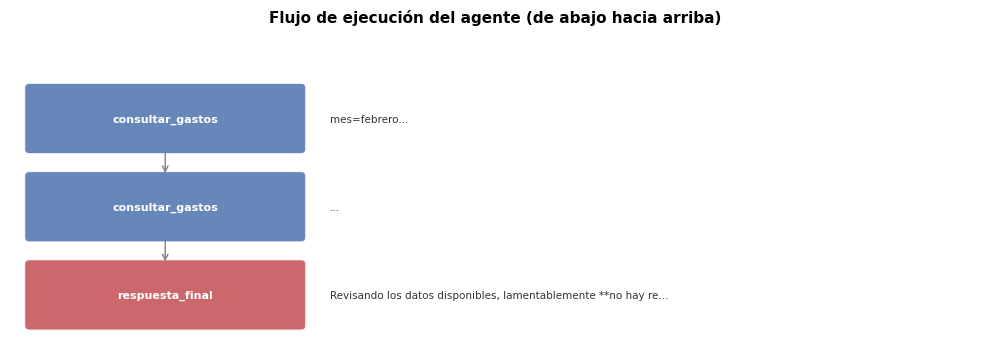

In [16]:
# Visualización gráfica de la traza
colores = {
    "consultar_gastos": "#4C72B0",
    "calcular":         "#55A868",
    "obtener_fecha":    "#DD8452",
    "respuesta_final":  "#C44E52",
}

fig, ax = plt.subplots(figsize=(10, max(3, len(traza) * 1.2)))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, len(traza))
ax.axis('off')

for i, paso in enumerate(reversed(traza)):
    y = i
    if paso['tipo'] == 'tool_call':
        color = colores.get(paso['herramienta'], '#888888')
        etiqueta = paso['herramienta']
        params_str = ", ".join(f"{k}={v}" for k, v in paso['parametros'].items())
        texto_der = params_str[:60]
    else:
        color = colores['respuesta_final']
        etiqueta = "respuesta_final"
        texto_der = paso['texto'][:60]

    rect = mpatches.FancyBboxPatch(
        (0.2, y - 0.35), 2.8, 0.7,
        boxstyle="round,pad=0.05", fc=color, alpha=0.85, ec='white'
    )
    ax.add_patch(rect)
    ax.text(1.6, y, etiqueta, ha='center', va='center',
            fontsize=8, color='white', fontweight='bold')
    ax.text(3.3, y, texto_der + "...", ha='left', va='center',
            fontsize=7.5, color='#333333')

    if i < len(traza) - 1:
        ax.annotate('', xy=(1.6, y + 0.35), xytext=(1.6, y + 0.65),
                    arrowprops=dict(arrowstyle='->', color='gray'))

ax.set_title('Flujo de ejecución del agente (de abajo hacia arriba)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Seguridad: Herramientas Responsables

Las herramientas que acepta el agente deben diseñarse con cuidado.
Algunos principios clave:

In [17]:
# ✗ MAL: eval sin restricciones — permite ejecutar cualquier código
def calcular_inseguro(expresion):
    return eval(expresion)  # ¡PELIGROSO!

# ✓ BIEN: eval con lista blanca de funciones permitidas
def calcular_seguro(expresion):
    funciones_permitidas = {
        "__builtins__": {},
        "sum": sum, "max": max, "min": min,
        "round": round, "abs": abs, "len": len,
    }
    try:
        return eval(expresion, funciones_permitidas)
    except Exception as e:
        return f"Error: {e}"

print("Seguro — suma:",    calcular_seguro("sum([1, 2, 3])"))
print("Seguro — intento de import:",
      calcular_seguro("__import__('os').listdir('.')"))

print()
print("Otros principios de seguridad:")
print("  1. Validar todos los parámetros antes de ejecutar")
print("  2. Imponer max_pasos para evitar loops infinitos")
print("  3. Limitar acceso al sistema de archivos y red")
print("  4. Registrar todas las llamadas a herramientas (logs)")

Seguro — suma: 6
Seguro — intento de import: Error: name '__import__' is not defined

Otros principios de seguridad:
  1. Validar todos los parámetros antes de ejecutar
  2. Imponer max_pasos para evitar loops infinitos
  3. Limitar acceso al sistema de archivos y red
  4. Registrar todas las llamadas a herramientas (logs)


---
## 12. Ejercicios

Practica lo que aprendiste ampliando el agente con nuevas capacidades.

In [ ]:
# ── Ejercicio 1 ─────────────────────────────────────────────────────────────
# Agrega una herramienta 'listar_categorias' que devuelva todas
# las categorías únicas presentes en gastos.json, sin parámetros.
#
# Pista: usa set() para obtener valores únicos.

# Tu código aquí:


In [ ]:
# ── Ejercicio 2 ─────────────────────────────────────────────────────────────
# Modifica el system prompt para que el agente:
#   a) Siempre empiece su respuesta con un emoji relevante
#   b) Presente los montos con formato de moneda: $1,234.50
#   c) Al final de cada respuesta añada una recomendación de ahorro
#
# Prueba el agente modificado con la pregunta:
# "¿Cuáles son mis tres gastos individuales más altos de todo el período?"

# Tu código aquí:


In [ ]:
# ── Ejercicio 3 ─────────────────────────────────────────────────────────────
# Agrega una herramienta 'comparar_meses' que reciba dos meses
# y devuelva un JSON con el total de cada mes y la diferencia porcentual.
#
# Prueba con: "Compara mis gastos de enero y marzo. ¿En cuánto aumentaron?"

# Tu código aquí:


---
## Resumen

En esta sesión construimos un agente funcional desde cero:

✅ **El loop del agente:** observación → razonamiento → acción → repetir  
✅ **IA vs determinista:** el LLM decide, el código ejecuta con precisión  
✅ **Tipos de prompts:** system (persona), user (tarea), assistant (historial)  
✅ **Herramientas:** definición con JSON schema, ejecución segura  
✅ **stop_reason:** `tool_use` para continuar, `end_turn` para terminar  
✅ **Agente financiero:** consultas, cálculos e interpretación en lenguaje natural  

**Próxima sesión:** patrones de razonamiento avanzados, memoria entre pasos y coordinación multi-agente.